# Effect of Covariate Shift on Prevalence Estimation

## Simulation Setup

We investigate how different calibration methods perform when estimating population prevalence under covariate shift. The simulation generates synthetic data with a binary covariate $X \in \{0, 1\}$ and binary outcome $Y \in \{0, 1\}$, where $X$ is predictive of $Y$:

$$P(Y=1|X=1) = 0.85, \quad P(Y=1|X=0) = 0.15$$

A classifier produces probability estimates $\hat{p}$ that are systematically biased:
- For $X=0$: $\hat{p} = P(Y=1|X=0) \times 0.9$ (underestimates)
- For $X=1$: $\hat{p} = P(Y=1|X=1) \times 1.1$ (overestimates)

Calibration parameters are learned on a training distribution with $P(X=0) = 0.5$. We then evaluate prevalence estimation bias across shifted distributions where $P(X=0)$ varies from 0.01 to 0.99.

## Methods Compared

1. **Uncalibrated**: Raw average of predicted probabilities $\bar{p} = \frac{1}{n}\sum_i \hat{p}_i$

2. **Classify and Count (CC)**: Binarize predictions at a threshold $\tau$ learned on calibration data, then compute proportion: $\hat{\pi}_{CC} = \frac{1}{n}\sum_i \mathbb{1}[\hat{p}_i \geq \tau]$. The threshold is chosen to match true prevalence on the calibration set.

3. **Rogan-Gladen Adjustment**: Classical epidemiological correction using estimated sensitivity (TPR) and specificity (1-FPR): $\hat{\pi}_{RG} = \frac{\bar{p} - \text{FPR}}{\text{TPR} - \text{FPR}}$, where TPR $= \mathbb{E}[\hat{p}|Y=1]$ and FPR $= \mathbb{E}[\hat{p}|Y=0]$

4. **Global Calibration**: Multiplicative correction factor $\alpha$ learned on calibration data: $\hat{\pi}_{cal} = \alpha \cdot \bar{p}$, where $\alpha = \bar{Y}_{cal} / \bar{p}_{cal}$

5. **SLD (Saerens-Latinne-Decaestecker)**: EM algorithm that iteratively re-estimates prevalence by adjusting posteriors for a new prior. Assumes label shift ($P(X|Y)$ stable), making it the strongest standard quantification method---but it fails under covariate shift.

6. **Multicalibration**: Additive adjustments learned per stratum: $\hat{\pi}_{MC} = \frac{1}{n}\sum_i (\hat{p}_i + \delta_{X_i})$, where $\delta_x = \mathbb{E}[Y|X=x] - \mathbb{E}[\hat{p}|X=x]$

In [1]:
import numpy as np
import pandas as pd

n = 10_000


def generate_data(n_samples, p_x0, p_y_given_x1, bias_b, bias_c):
    X = np.random.choice([0, 1], size=n_samples, p=[p_x0, 1 - p_x0])

    Y = np.array(
        [np.random.binomial(1, p_y_given_x1 if x == 1 else 1 - p_y_given_x1) for x in X]
    )

    p_estimated = np.array(
        [(1 - p_y_given_x1) * bias_b if x == 0 else p_y_given_x1 * bias_c for x in X]
    )

    assert p_estimated.min() >= 0 and p_estimated.max() <= 1, "Invalid probabilities"

    data = pd.DataFrame({"X": X, "Y": Y, "p_estimated": p_estimated})

    return data


n_samples = n
p_x0 = 0.5
p_y_given_x1 = 0.85
bias_b = 0.9
bias_c = 1.1

data = generate_data(n_samples, p_x0, p_y_given_x1, bias_b, bias_c)

print("Global Prevalence Estimate (p_bar):", data["p_estimated"].mean())
print("True Global Prevalence:", data["Y"].mean())
print(
    "Bias in Prevalence Measurement:",
    (data["p_estimated"].mean() - data["Y"].mean()) / data["Y"].mean() * 100,
)

print(
    f"P(Y=1|X=0) true: {1 - p_y_given_x1:.3f}, estimated: {data[data['X']==0]['p_estimated'].mean():.3f}"
)
print(
    f"P(Y=1|X=1) true: {p_y_given_x1:.3f}, estimated: {data[data['X']==1]['p_estimated'].mean():.3f}"
)

Global Prevalence Estimate (p_bar): 0.5333200000000001
True Global Prevalence: 0.4989
Bias in Prevalence Measurement: 6.8991781920224735
P(Y=1|X=0) true: 0.150, estimated: 0.135
P(Y=1|X=1) true: 0.850, estimated: 0.935


In [2]:
import os
os.makedirs("../paper/images", exist_ok=True)

In [3]:
tpr_estimated = data[data['Y'] == 1]['p_estimated'].mean()
fpr_estimated = data[data['Y'] == 0]['p_estimated'].mean()

p_unadjusted = data['p_estimated'].mean()

p_adjusted_rogan_gladen = (p_unadjusted - fpr_estimated) / (tpr_estimated - fpr_estimated)

print(f"TPR (E[p|Y=1]): {tpr_estimated:.4f}")
print(f"FPR (E[p|Y=0]): {fpr_estimated:.4f}")
print(f"Unadjusted prevalence: {p_unadjusted:.4f}")
print(f"Rogan-Gladen adjusted prevalence: {p_adjusted_rogan_gladen:.4f}")
print(f"True prevalence: {data['Y'].mean():.4f}")

TPR (E[p|Y=1]): 0.8184
FPR (E[p|Y=0]): 0.2495
Unadjusted prevalence: 0.5333
Rogan-Gladen adjusted prevalence: 0.4989
True prevalence: 0.4989


In [4]:
rg_tpr = tpr_estimated
rg_fpr = fpr_estimated

print(f"Stored R-G parameters from training data:")
print(f"  TPR (E[p|Y=1]): {rg_tpr:.4f}")
print(f"  FPR (E[p|Y=0]): {rg_fpr:.4f}")

Stored R-G parameters from training data:
  TPR (E[p|Y=1]): 0.8184
  FPR (E[p|Y=0]): 0.2495


In [5]:
def apply_rogan_gladen(p_unadjusted, tpr, fpr):
    return (p_unadjusted - fpr) / (tpr - fpr)


def sld_estimate(scores, source_prevalence, max_iter=100, tol=1e-6):
    """Saerens-Latinne-Decaestecker (EMQ) prevalence estimator.
    
    EM algorithm that iteratively re-estimates prevalence by adjusting
    posteriors for a new prior. Assumes label shift (P(X|Y) stable).
    """
    p_hat = source_prevalence
    for _ in range(max_iter):
        ratio_pos = p_hat / source_prevalence
        ratio_neg = (1 - p_hat) / (1 - source_prevalence)
        adjusted = (ratio_pos * scores) / (ratio_pos * scores + ratio_neg * (1 - scores))
        p_new = adjusted.mean()
        if abs(p_new - p_hat) < tol:
            break
        p_hat = p_new
    return p_hat

In [6]:
n_calibration_samples = n
calibration_data = generate_data(
    n_calibration_samples, p_x0, p_y_given_x1, bias_b, bias_c
)

observed_prevalence = calibration_data["Y"].mean()
estimated_prevalence = calibration_data["p_estimated"].mean()
calibration_factor = observed_prevalence / estimated_prevalence

calibrated_data = data.copy()
calibrated_data["p_estimated_calibrated"] = (
    calibrated_data["p_estimated"] * calibration_factor
)

p_bar_calibrated = calibrated_data["p_estimated_calibrated"].mean()

print(f"True mean of Y: {data['Y'].mean():.3f}")
print(f"Estimated mean using p_estimated: {data['p_estimated'].mean():.3f}")
print(f"Estimated mean using p_estimated_calibrated: {p_bar_calibrated:.3f}")

True mean of Y: 0.499
Estimated mean using p_estimated: 0.533
Estimated mean using p_estimated_calibrated: 0.499


In [7]:
def compute_multicalibration_factors(data):
    calibration_adjustments = {}
    for x_value in [0, 1]:
        subset = data[data["X"] == x_value]
        observed_prevalence = subset["Y"].mean()
        estimated_prevalence = subset["p_estimated"].mean()
        calibration_adjustments[x_value] = observed_prevalence - estimated_prevalence
    return calibration_adjustments

In [8]:
multicalibration_adjustments = compute_multicalibration_factors(calibration_data)

print("Estimated Multicalibration adjustments (additive):")
for x_val in [0, 1]:
    print(f"  X={x_val}: {multicalibration_adjustments[x_val]:+.4f}")

Estimated Multicalibration adjustments (additive):
  X=0: +0.0202
  X=1: -0.0888


In [9]:
for x_value in [0, 1]:
    if x_value == 0:
        true_p_y_given_x = 1 - p_y_given_x1
    else:
        true_p_y_given_x = p_y_given_x1

    estimated_p_y_given_x = calibration_data[calibration_data['X'] == x_value]['p_estimated'].mean()
    multicalibration_adjustment = multicalibration_adjustments[x_value]
    adjusted_estimates = estimated_p_y_given_x + multicalibration_adjustment

    print(f"For X={x_value}:")
    print(f"  True P(Y|X={x_value}): {true_p_y_given_x:.3f}")
    print(f"  Estimated P(Y|X={x_value}): {estimated_p_y_given_x:.3f}")
    print(f"  Adjusted P(Y|X={x_value}): {adjusted_estimates:.3f}\n")

For X=0:
  True P(Y|X=0): 0.150
  Estimated P(Y|X=0): 0.135
  Adjusted P(Y|X=0): 0.155

For X=1:
  True P(Y|X=1): 0.850
  Estimated P(Y|X=1): 0.935
  Adjusted P(Y|X=1): 0.846



In [10]:
new_sample = generate_data(n_samples=n, p_x0=p_x0, p_y_given_x1=p_y_given_x1, bias_b=bias_b, bias_c=bias_c)

uncalibrated_prevalence = new_sample['p_estimated'].mean()

new_sample['p_estimated_calibrated'] = new_sample['p_estimated'] * calibration_factor
calibrated_prevalence = new_sample['p_estimated_calibrated'].mean()

new_sample['p_estimated_multicalibrated'] = new_sample.apply(
    lambda row: row['p_estimated'] + multicalibration_adjustments[row['X']], axis=1
)
multicalibrated_prevalence = new_sample['p_estimated_multicalibrated'].mean()

true_prevalence = (p_x0 * (1 - p_y_given_x1)) + ((1 - p_x0) * p_y_given_x1)
print(f"True Prevalence (from config): {true_prevalence:.3f}")

print(f"Global Uncalibrated Prevalence: {uncalibrated_prevalence:.3f}")
print(f"Global Calibrated Prevalence: {calibrated_prevalence:.3f}")
print(f"Global Multicalibrated Prevalence: {multicalibrated_prevalence:.3f}")

True Prevalence (from config): 0.500
Global Uncalibrated Prevalence: 0.537
Global Calibrated Prevalence: 0.503
Global Multicalibrated Prevalence: 0.503


In [11]:
def analyze_shifted_distribution(
    shifted_p_x0, calibration_factor, multicalibration_adjustments, rg_tpr, rg_fpr, cc_threshold, source_prevalence
):
    shifted_sample = generate_data(
        n_samples=n,
        p_x0=shifted_p_x0,
        p_y_given_x1=p_y_given_x1,
        bias_b=bias_b,
        bias_c=bias_c,
    )

    uncalibrated_prevalence_shifted = shifted_sample["p_estimated"].mean()

    cc_prevalence_shifted = (shifted_sample["p_estimated"] >= cc_threshold).mean()

    rg_prevalence_shifted = apply_rogan_gladen(uncalibrated_prevalence_shifted, rg_tpr, rg_fpr)

    sld_prevalence_shifted = sld_estimate(shifted_sample["p_estimated"].values, source_prevalence)

    shifted_sample["p_estimated_calibrated"] = (
        shifted_sample["p_estimated"] * calibration_factor
    )
    calibrated_prevalence_shifted = shifted_sample["p_estimated_calibrated"].mean()

    shifted_sample["p_estimated_multicalibrated"] = shifted_sample.apply(
        lambda row: row["p_estimated"] + multicalibration_adjustments[row["X"]], axis=1
    )
    multicalibrated_prevalence_shifted = shifted_sample[
        "p_estimated_multicalibrated"
    ].mean()

    true_prevalence_shifted = (shifted_p_x0 * (1 - p_y_given_x1)) + (
        (1 - shifted_p_x0) * p_y_given_x1
    )

    return (
        shifted_sample,
        true_prevalence_shifted,
        uncalibrated_prevalence_shifted,
        cc_prevalence_shifted,
        rg_prevalence_shifted,
        sld_prevalence_shifted,
        calibrated_prevalence_shifted,
        multicalibrated_prevalence_shifted,
    )


def learn_cc_threshold(calib_data):
    true_prev = calib_data['Y'].mean()
    p_values = np.sort(calib_data['p_estimated'].unique())

    best_threshold = 0.5
    best_error = float('inf')

    for threshold in p_values:
        cc_prev = (calib_data['p_estimated'] >= threshold).mean()
        error = abs(cc_prev - true_prev)
        if error < best_error:
            best_error = error
            best_threshold = threshold

    return best_threshold


cc_threshold = learn_cc_threshold(calibration_data)
source_prevalence = calibration_data['Y'].mean()
print(f"Learned Classify and Count threshold: {cc_threshold:.4f}")
print(f"CC prevalence with learned threshold: {(calibration_data['p_estimated'] >= cc_threshold).mean():.4f}")
print(f"True prevalence: {calibration_data['Y'].mean():.4f}")
print(f"Source prevalence for SLD: {source_prevalence:.4f}")

(
    shifted_sample_data,
    true_prev,
    uncal_prev,
    cc_prev,
    rg_prev,
    sld_prev,
    cal_prev,
    multi_cal_prev,
) = analyze_shifted_distribution(
    shifted_p_x0=0.1,
    calibration_factor=calibration_factor,
    multicalibration_adjustments=multicalibration_adjustments,
    rg_tpr=rg_tpr,
    rg_fpr=rg_fpr,
    cc_threshold=cc_threshold,
    source_prevalence=source_prevalence,
)

print(f"\nTrue Prevalence in Shifted Distribution: {true_prev:.3f}")
print(f"Global Uncalibrated Prevalence in Shifted Distribution: {uncal_prev:.3f}")
print(f"Classify and Count Prevalence in Shifted Distribution: {cc_prev:.3f}")
print(f"Rogan-Gladen Adjusted Prevalence in Shifted Distribution: {rg_prev:.3f}")
print(f"SLD (EMQ) Prevalence in Shifted Distribution: {sld_prev:.3f}")
print(f"Global Calibrated Prevalence in Shifted Distribution: {cal_prev:.3f}")
print(
    f"Global Multicalibrated Prevalence in Shifted Distribution: {multi_cal_prev:.3f}"
)

print(f"\nBias Classify and Count: {100 * (cc_prev - true_prev) / true_prev:.2f}%")
print(f"Bias Rogan-Gladen: {100 * (rg_prev - true_prev) / true_prev:.2f}%")
print(f"Bias SLD: {100 * (sld_prev - true_prev) / true_prev:.2f}%")
print(f"Bias calibrated: {100 * (cal_prev - true_prev) / true_prev:.2f}%")
print(f"Bias multicalibrated: {100 * (multi_cal_prev - true_prev) / true_prev:.2f}%")

Learned Classify and Count threshold: 0.9350
CC prevalence with learned threshold: 0.5046
True prevalence: 0.5039
Source prevalence for SLD: 0.5039

True Prevalence in Shifted Distribution: 0.780
Global Uncalibrated Prevalence in Shifted Distribution: 0.854
Classify and Count Prevalence in Shifted Distribution: 0.899
Rogan-Gladen Adjusted Prevalence in Shifted Distribution: 1.063
SLD (EMQ) Prevalence in Shifted Distribution: 1.000
Global Calibrated Prevalence in Shifted Distribution: 0.799
Global Multicalibrated Prevalence in Shifted Distribution: 0.776

Bias Classify and Count: 15.27%
Bias Rogan-Gladen: 36.28%
Bias SLD: 28.20%
Bias calibrated: 2.45%
Bias multicalibrated: -0.45%


In [12]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.dpi': 150,
})


def compute_bias_curve(
    n_samples,
    p_y_given_x1,
    bias_b,
    bias_c,
    calibration_factor,
    multicalibration_adjustments,
    rg_tpr,
    rg_fpr,
    cc_threshold,
    source_prevalence,
    original_p_x0=0.5,
    shift_range=(0.01, 0.99),
    n_points=20,
):
    distribution_shifts = np.linspace(shift_range[0], shift_range[1], n_points)
    deltas = distribution_shifts - original_p_x0

    bias_percentage_uncalibrated = []
    bias_percentage_cc = []
    bias_percentage_rg = []
    bias_percentage_sld = []
    bias_percentage_global = []
    bias_percentage_multi = []

    se_uncalibrated = []
    se_cc = []
    se_rg = []
    se_sld = []
    se_global = []
    se_multi = []

    for p_x0_shifted in distribution_shifts:

        (
            shifted_sample,
            true_prevalence_shifted,
            uncalibrated_prevalence_shifted,
            cc_prevalence_shifted,
            rg_prevalence_shifted,
            sld_prevalence_shifted,
            calibrated_prevalence_shifted,
            multicalibrated_prevalence_shifted
        ) = analyze_shifted_distribution(
            shifted_p_x0=p_x0_shifted,
            calibration_factor=calibration_factor,
            multicalibration_adjustments=multicalibration_adjustments,
            rg_tpr=rg_tpr,
            rg_fpr=rg_fpr,
            cc_threshold=cc_threshold,
            source_prevalence=source_prevalence,
        )

        true_mean_y = shifted_sample["Y"].mean()

        bias_pct_uncalibrated = 100 * (uncalibrated_prevalence_shifted - true_mean_y) / true_mean_y
        bias_pct_cc = 100 * (cc_prevalence_shifted - true_mean_y) / true_mean_y
        bias_pct_rg = 100 * (rg_prevalence_shifted - true_mean_y) / true_mean_y
        bias_pct_sld = 100 * (sld_prevalence_shifted - true_mean_y) / true_mean_y
        bias_pct_global = 100 * (calibrated_prevalence_shifted - true_mean_y) / true_mean_y
        bias_pct_multi = 100 * (multicalibrated_prevalence_shifted - true_mean_y) / true_mean_y

        bias_percentage_uncalibrated.append(bias_pct_uncalibrated)
        bias_percentage_cc.append(bias_pct_cc)
        bias_percentage_rg.append(bias_pct_rg)
        bias_percentage_sld.append(bias_pct_sld)
        bias_percentage_global.append(bias_pct_global)
        bias_percentage_multi.append(bias_pct_multi)

        # Squared error (in percentage points squared) for MSE
        se_uncalibrated.append((100 * (uncalibrated_prevalence_shifted - true_mean_y)) ** 2)
        se_cc.append((100 * (cc_prevalence_shifted - true_mean_y)) ** 2)
        se_rg.append((100 * (rg_prevalence_shifted - true_mean_y)) ** 2)
        se_sld.append((100 * (sld_prevalence_shifted - true_mean_y)) ** 2)
        se_global.append((100 * (calibrated_prevalence_shifted - true_mean_y)) ** 2)
        se_multi.append((100 * (multicalibrated_prevalence_shifted - true_mean_y)) ** 2)

    return {
        "deltas": np.array(deltas),
        "bias_uncalibrated": np.array(bias_percentage_uncalibrated),
        "bias_cc": np.array(bias_percentage_cc),
        "bias_rg": np.array(bias_percentage_rg),
        "bias_sld": np.array(bias_percentage_sld),
        "bias_global": np.array(bias_percentage_global),
        "bias_multi": np.array(bias_percentage_multi),
        "se_uncalibrated": np.array(se_uncalibrated),
        "se_cc": np.array(se_cc),
        "se_rg": np.array(se_rg),
        "se_sld": np.array(se_sld),
        "se_global": np.array(se_global),
        "se_multi": np.array(se_multi),
    }

In [13]:
def compute_bias_curves_bootstrap(
    B,
    n_samples,
    n_calibration,
    p_x0,
    p_y_given_x1,
    bias_b,
    bias_c,
    original_p_x0=0.5,
    shift_range=(0.01, 0.99),
    n_points=20,
):
    all_uncalibrated_curves = []
    all_cc_curves = []
    all_rg_curves = []
    all_sld_curves = []
    all_calibrated_curves = []
    all_multicalibrated_curves = []

    all_se_uncalibrated = []
    all_se_cc = []
    all_se_rg = []
    all_se_sld = []
    all_se_calibrated = []
    all_se_multicalibrated = []

    deltas = None

    for b in range(B):
        calib_data = generate_data(n_calibration, p_x0, p_y_given_x1, bias_b, bias_c)

        iter_rg_tpr = calib_data[calib_data['Y'] == 1]['p_estimated'].mean()
        iter_rg_fpr = calib_data[calib_data['Y'] == 0]['p_estimated'].mean()
        iter_calibration_factor = calib_data['Y'].mean() / calib_data['p_estimated'].mean()
        iter_multicalibration_adjustments = compute_multicalibration_factors(calib_data)
        iter_cc_threshold = learn_cc_threshold(calib_data)
        iter_source_prevalence = calib_data['Y'].mean()

        result = compute_bias_curve(
            n_samples=n_samples,
            p_y_given_x1=p_y_given_x1,
            bias_b=bias_b,
            bias_c=bias_c,
            calibration_factor=iter_calibration_factor,
            multicalibration_adjustments=iter_multicalibration_adjustments,
            rg_tpr=iter_rg_tpr,
            rg_fpr=iter_rg_fpr,
            cc_threshold=iter_cc_threshold,
            source_prevalence=iter_source_prevalence,
            original_p_x0=original_p_x0,
            shift_range=shift_range,
            n_points=n_points,
        )

        if deltas is None:
            deltas = result["deltas"]

        all_uncalibrated_curves.append(result["bias_uncalibrated"])
        all_cc_curves.append(result["bias_cc"])
        all_rg_curves.append(result["bias_rg"])
        all_sld_curves.append(result["bias_sld"])
        all_calibrated_curves.append(result["bias_global"])
        all_multicalibrated_curves.append(result["bias_multi"])

        all_se_uncalibrated.append(result["se_uncalibrated"])
        all_se_cc.append(result["se_cc"])
        all_se_rg.append(result["se_rg"])
        all_se_sld.append(result["se_sld"])
        all_se_calibrated.append(result["se_global"])
        all_se_multicalibrated.append(result["se_multi"])

    all_uncalibrated_curves = np.array(all_uncalibrated_curves)
    all_cc_curves = np.array(all_cc_curves)
    all_rg_curves = np.array(all_rg_curves)
    all_sld_curves = np.array(all_sld_curves)
    all_calibrated_curves = np.array(all_calibrated_curves)
    all_multicalibrated_curves = np.array(all_multicalibrated_curves)

    all_se_uncalibrated = np.array(all_se_uncalibrated)
    all_se_cc = np.array(all_se_cc)
    all_se_rg = np.array(all_se_rg)
    all_se_sld = np.array(all_se_sld)
    all_se_calibrated = np.array(all_se_calibrated)
    all_se_multicalibrated = np.array(all_se_multicalibrated)

    return {
        "deltas": deltas,
        "all_uncalibrated": all_uncalibrated_curves,
        "all_cc": all_cc_curves,
        "all_rg": all_rg_curves,
        "all_sld": all_sld_curves,
        "all_calibrated": all_calibrated_curves,
        "all_multicalibrated": all_multicalibrated_curves,
        "avg_uncalibrated": np.mean(all_uncalibrated_curves, axis=0),
        "avg_cc": np.mean(all_cc_curves, axis=0),
        "avg_rg": np.mean(all_rg_curves, axis=0),
        "avg_sld": np.mean(all_sld_curves, axis=0),
        "avg_calibrated": np.mean(all_calibrated_curves, axis=0),
        "avg_multicalibrated": np.mean(all_multicalibrated_curves, axis=0),
        # MSE = mean of squared errors across bootstrap iterations
        "mse_uncalibrated": np.mean(all_se_uncalibrated, axis=0),
        "mse_cc": np.mean(all_se_cc, axis=0),
        "mse_rg": np.mean(all_se_rg, axis=0),
        "mse_sld": np.mean(all_se_sld, axis=0),
        "mse_calibrated": np.mean(all_se_calibrated, axis=0),
        "mse_multicalibrated": np.mean(all_se_multicalibrated, axis=0),
    }

In [14]:
B = 50
print(f"Computing {B} bias curves...")

bias_curves_results = compute_bias_curves_bootstrap(
    B=B,
    n_samples=n,
    n_calibration=n,
    p_x0=p_x0,
    p_y_given_x1=p_y_given_x1,
    bias_b=bias_b,
    bias_c=bias_c,
    original_p_x0=p_x0,
    shift_range=(0.01, 0.99),
    n_points=20,
)

print(f"Completed computing {B} bias curves!")

Computing 50 bias curves...


Completed computing 50 bias curves!


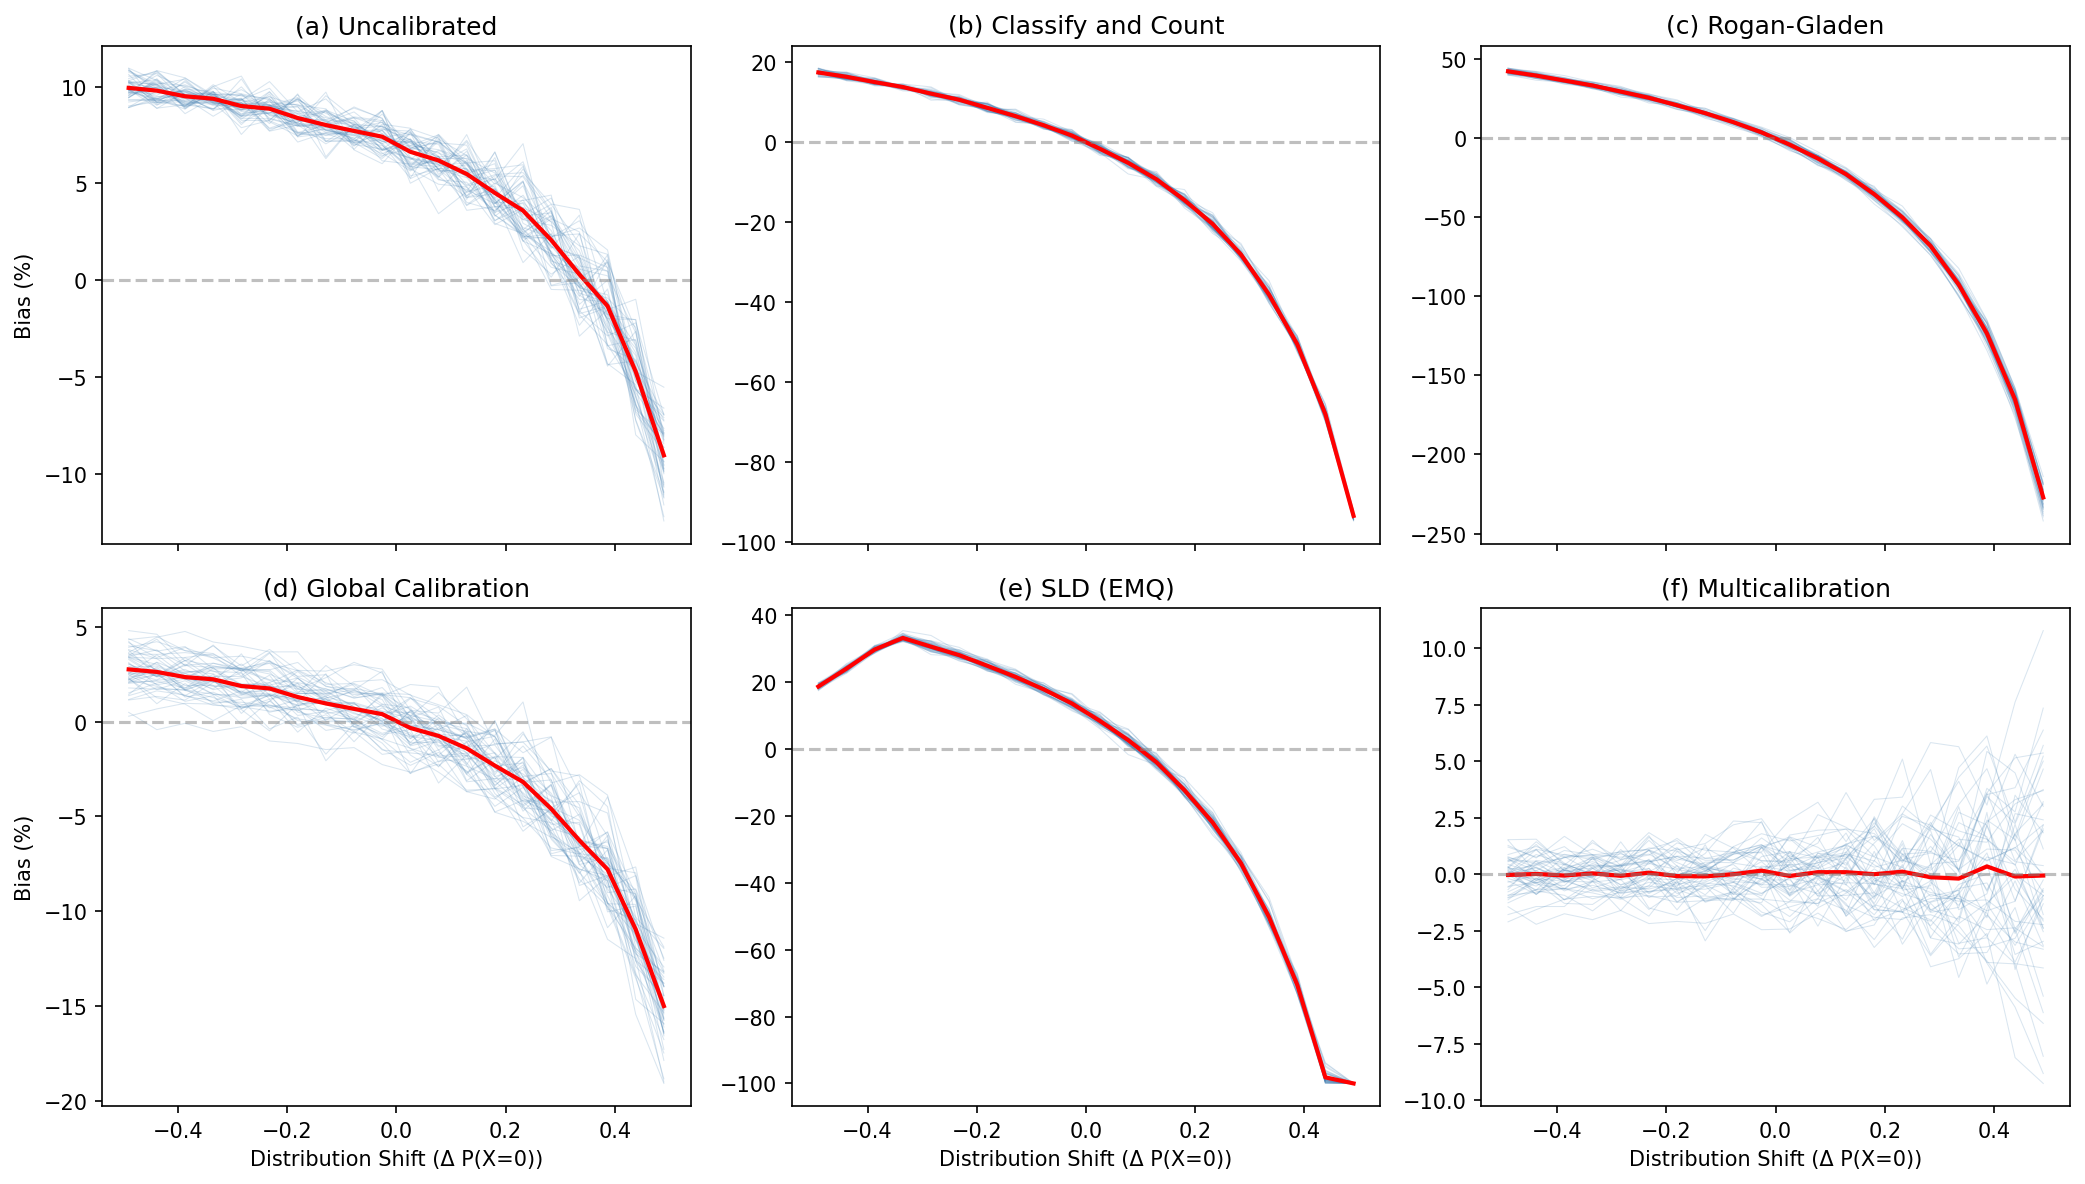

In [15]:
# Per-method bias panels (6-panel figure)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)

panels = [
    (0, 0, bias_curves_results["all_uncalibrated"], bias_curves_results["avg_uncalibrated"], "(a) Uncalibrated"),
    (0, 1, bias_curves_results["all_cc"], bias_curves_results["avg_cc"], "(b) Classify and Count"),
    (0, 2, bias_curves_results["all_rg"], bias_curves_results["avg_rg"], "(c) Rogan-Gladen"),
    (1, 0, bias_curves_results["all_calibrated"], bias_curves_results["avg_calibrated"], "(d) Global Calibration"),
    (1, 1, bias_curves_results["all_sld"], bias_curves_results["avg_sld"], "(e) SLD (EMQ)"),
    (1, 2, bias_curves_results["all_multicalibrated"], bias_curves_results["avg_multicalibrated"], "(f) Multicalibration"),
]

deltas = bias_curves_results["deltas"]

for row, col, all_curves, avg_curve, title in panels:
    ax = axes[row, col]
    for i in range(all_curves.shape[0]):
        ax.plot(deltas, all_curves[i], color="steelblue", linewidth=0.5, alpha=0.2)
    ax.plot(deltas, avg_curve, color="red", linewidth=2)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(title)
    if col == 0:
        ax.set_ylabel("Bias (%)")
    if row == 1:
        ax.set_xlabel("Distribution Shift (Δ P(X=0))")

plt.tight_layout()
plt.savefig("../paper/images/figure1_simulation_bias.png", dpi=300, bbox_inches="tight")
plt.show()

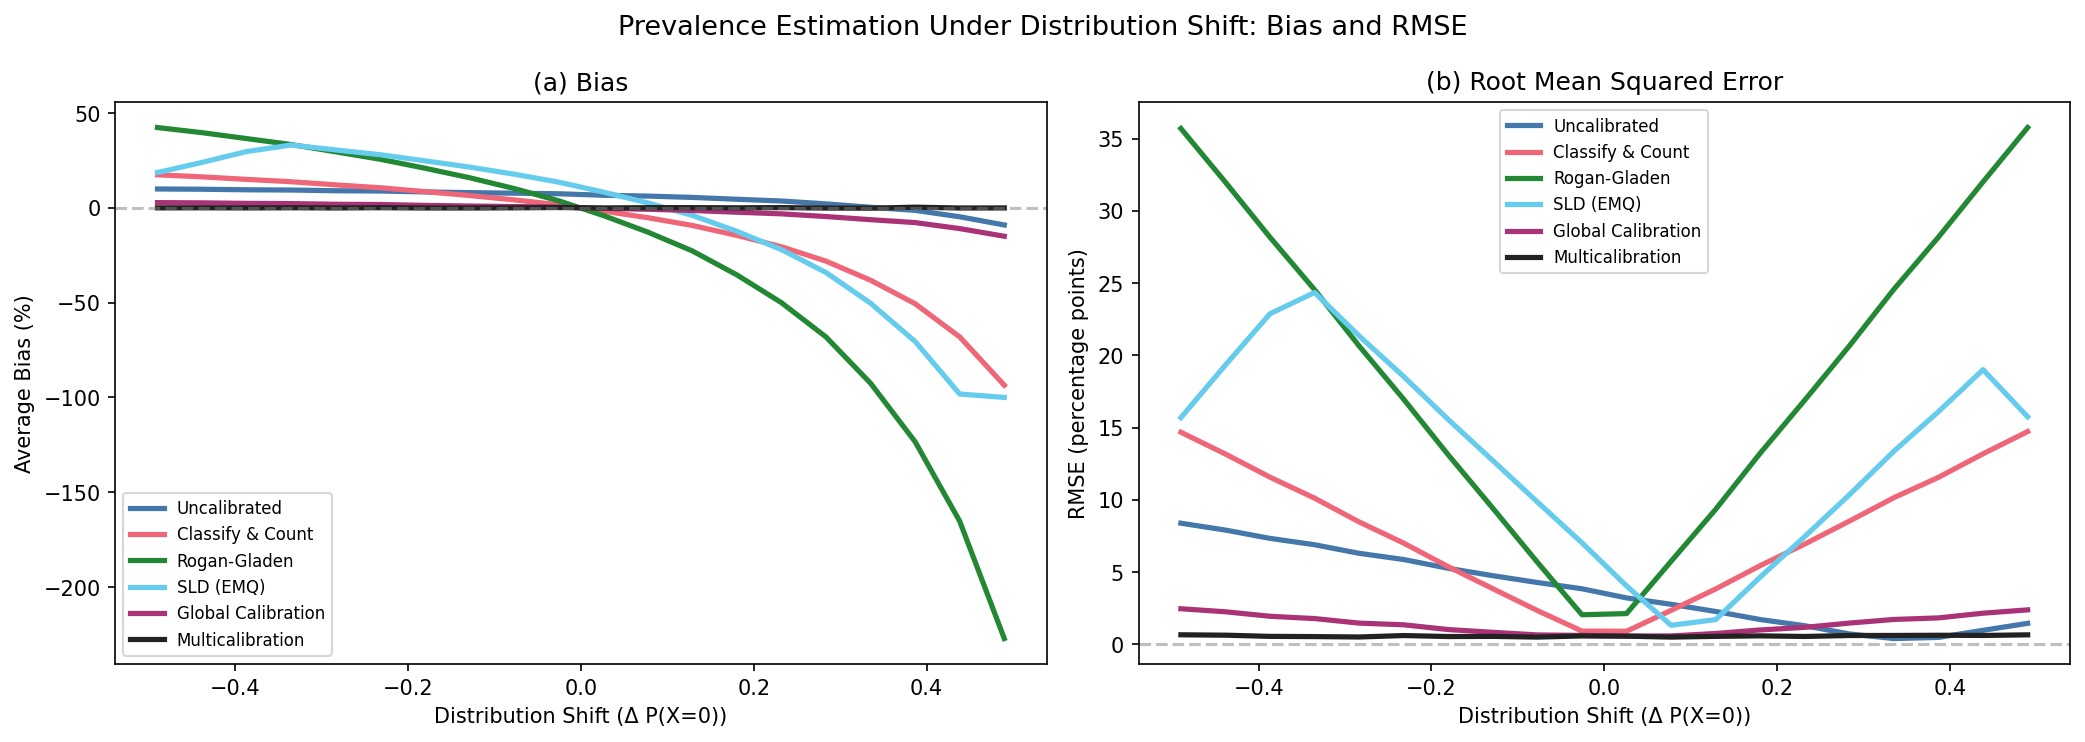

In [16]:
import sys
sys.path.insert(0, "..")
from plot_config import METHOD_COLORS

# Combined figure: Bias (left) and RMSE (right) for all methods
methods_list = [
    ("Uncalibrated", "avg_uncalibrated", "mse_uncalibrated"),
    ("Classify & Count", "avg_cc", "mse_cc"),
    ("Rogan-Gladen", "avg_rg", "mse_rg"),
    ("SLD (EMQ)", "avg_sld", "mse_sld"),
    ("Global Calibration", "avg_calibrated", "mse_calibrated"),
    ("Multicalibration", "avg_multicalibrated", "mse_multicalibrated"),
]

deltas = bias_curves_results["deltas"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Average Bias
for name, bias_key, mse_key in methods_list:
    ax1.plot(deltas, bias_curves_results[bias_key], color=METHOD_COLORS[name], linewidth=2.5, label=name)
ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("Distribution Shift (Δ P(X=0))")
ax1.set_ylabel("Average Bias (%)")
ax1.set_title("(a) Bias")
ax1.legend(fontsize=8)

# Right panel: RMSE
for name, bias_key, mse_key in methods_list:
    rmse = np.sqrt(bias_curves_results[mse_key])
    ax2.plot(deltas, rmse, color=METHOD_COLORS[name], linewidth=2.5, label=name)
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Distribution Shift (Δ P(X=0))")
ax2.set_ylabel("RMSE (percentage points)")
ax2.set_title("(b) Root Mean Squared Error")
ax2.legend(fontsize=8)

fig.suptitle("Prevalence Estimation Under Distribution Shift: Bias and RMSE", fontsize=13)
fig.tight_layout()
fig.savefig("../paper/images/figure_multicalibration_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
